# Etapa 7 — Avaliação Cruzada · Stage 5 (horizonte 5 dias + features derivadas)

Este notebook reavalia os 4 modelos do projeto (BiLSTM original, BiLSTM reduzido, XGBoost, Transformer) sobre o dataset **Dataset Etapa 4 + 16 features temporais derivadas (MA7/MA21 do sentimento, deltas, razão pos/neg, volatilidade)**, usando os utilitários compartilhados em `shared/` para garantir comparabilidade entre etapas.

## Protocolo

- Split walk-forward 70/15/15 (sem leakage temporal).
- Mesma normalização e mesmo target binário (sobe/desce).
- Métricas reportadas: **ROC-AUC** (primária), F1 por classe, accuracy, matriz de confusão.
- Resultados salvos em `results/` para consolidação cross-stage.

## Hipótese desta configuração

Sentimento de notícias tem efeito de curto prazo capturável em horizonte de 5 dias úteis. *Resultado esperado: piora generalizada — o sinal do InfoMoney se manifesta no médio prazo (~21 dias).*

Ver `README.md` desta pasta e `BALANCEAMENTO_DE_CLASSES.md` para discussão de métricas em datasets desbalanceados.

In [1]:
import sys
import os
import logging

sys.path.insert(0, '.')

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")

from shared.data_loader import load_stage5_horizon5
from shared.trainer import train_and_evaluate, save_results_json
from shared.plots import (
    plot_roc_curves,
    plot_confusion_matrices,
    plot_calibration_diagrams,
    plot_temporal_stability,
    plot_prediction_distributions,
    plot_learning_curves,
    plot_feature_importance,
    plot_shap_summary,
)

print("Modulos carregados com sucesso")

19:01:20 [INFO] Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
19:01:20 [INFO] NumExpr defaulting to 16 threads.


Modulos carregados com sucesso


# Stage 5b: Horizonte 5 dias — Avaliacao Completa

Retreino dos 7 modelos com features engenheiradas de sentimento + preco. Dataset: ~1227 dias, 32 features, horizonte 5 dias.

In [2]:
data = load_stage5_horizon5(window=30)
print(f"Descricao: {data['description']}")
print(f"Sequencias: {data['X_seq'].shape}")
print(f"Tabular: {data['X_flat'].shape}")
print(f"Features: {data['feature_names']}")
print(f"Balance: {data['y_seq'].mean():.1%} sobe / {1-data['y_seq'].mean():.1%} desce")

Descricao: Stage 5b: FinBERT + features engenheiradas, horizonte 5 dias
Sequencias: (1172, 30, 32)
Tabular: (1202, 32)
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment', 'mean_logit_pos_ma7', 'mean_logit_pos_ma21', 'mean_logit_neg_ma7', 'mean_logit_neg_ma21', 'mean_logit_neu_ma7', 'mean_logit_neu_ma21', 'mean_sentiment_ma7', 'mean_sentiment_ma21', 'mean_logit_pos_delta7', 'mean_logit_neg_delta7', 'mean_sentiment_delta7', 'pos_neg_ratio', 'pos_neg_ratio_ma7', 'n_articles_sum7', 'n_articles_sum21', 'sentiment_std7']
Balance: 54.0% sobe / 46.0% desce


## Treino dos 7 modelos (configuracao padrao)

In [3]:
MODEL_CONFIGS = {
    "BiLSTM Original": {"model_name": "bilstm_original"},
    "BiLSTM Reduzido": {"model_name": "bilstm_reduced"},
    "Transformer": {"model_name": "transformer"},
    "TCN": {"model_name": "tcn"},
    "XGBoost": {"model_name": "xgboost"},
    "Logistic Regression": {"model_name": "logistic_regression"},
    "Random Forest": {"model_name": "random_forest"},
}

results = {}
for display_name, config in MODEL_CONFIGS.items():
    print(f"{'='*60}")
    print(f"Treinando: {display_name}")
    print(f"{'='*60}")
    results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        compute_shap=True,
        compute_learning_curve=True,
    )

19:01:22 [INFO] 
19:01:22 [INFO] Modelo: bilstm_original
19:01:22 [INFO] Split — treino: 820 | val: 175 | teste: 177
19:01:22 [INFO] ============================================================


Treinando: BiLSTM Original


19:01:22 [INFO] Class weights: sobe=0.903, desce=1.108 (balance: 52.6% sobe)
19:01:23 [INFO] Epoch   1/50 | loss 0.6933 | val_loss 0.6921 | val_acc 45.7% | lr 1.00e-03
19:01:23 [INFO] Epoch   2/50 | loss 0.6804 | val_loss 0.7150 | val_acc 40.6% | lr 1.00e-03
19:01:23 [INFO] Epoch   3/50 | loss 0.6616 | val_loss 0.7374 | val_acc 41.1% | lr 1.00e-03
19:01:23 [INFO] Epoch   4/50 | loss 0.6505 | val_loss 0.8469 | val_acc 49.1% | lr 1.00e-03
19:01:23 [INFO] Epoch   5/50 | loss 0.6340 | val_loss 0.8084 | val_acc 43.4% | lr 1.00e-03
19:01:23 [INFO] Epoch   6/50 | loss 0.6276 | val_loss 0.7691 | val_acc 46.3% | lr 1.00e-03
19:01:24 [INFO] Epoch   7/50 | loss 0.6297 | val_loss 0.7207 | val_acc 50.9% | lr 5.00e-04
19:01:24 [INFO] Epoch   8/50 | loss 0.5884 | val_loss 0.7675 | val_acc 46.9% | lr 5.00e-04
19:01:24 [INFO] Epoch   9/50 | loss 0.5606 | val_loss 0.8034 | val_acc 48.6% | lr 5.00e-04
19:01:24 [INFO] Epoch  10/50 | loss 0.5516 | val_loss 0.8349 | val_acc 42.3% | lr 5.00e-04
19:01:24 [INF

Treinando: BiLSTM Reduzido


19:01:24 [INFO] Epoch   2/50 | loss 0.6835 | val_loss 0.6886 | val_acc 49.7% | lr 1.00e-03
19:01:25 [INFO] Epoch   3/50 | loss 0.6704 | val_loss 0.6948 | val_acc 49.1% | lr 1.00e-03
19:01:25 [INFO] Epoch   4/50 | loss 0.6521 | val_loss 0.7115 | val_acc 48.0% | lr 1.00e-03
19:01:25 [INFO] Epoch   5/50 | loss 0.6291 | val_loss 0.7411 | val_acc 45.7% | lr 1.00e-03
19:01:25 [INFO] Epoch   6/50 | loss 0.6075 | val_loss 0.7673 | val_acc 48.0% | lr 1.00e-03
19:01:25 [INFO] Epoch   7/50 | loss 0.5823 | val_loss 0.7845 | val_acc 42.3% | lr 1.00e-03
19:01:25 [INFO] Epoch   8/50 | loss 0.5648 | val_loss 0.8341 | val_acc 42.9% | lr 5.00e-04
19:01:25 [INFO] Epoch   9/50 | loss 0.5549 | val_loss 0.8614 | val_acc 44.0% | lr 5.00e-04
19:01:25 [INFO] Epoch  10/50 | loss 0.5320 | val_loss 0.8766 | val_acc 40.0% | lr 5.00e-04
19:01:25 [INFO] Epoch  11/50 | loss 0.5387 | val_loss 0.8587 | val_acc 48.6% | lr 5.00e-04
19:01:25 [INFO] Epoch  12/50 | loss 0.4944 | val_loss 0.8552 | val_acc 43.4% | lr 5.00e-04

...

/home/takeo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:01:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:01:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:01:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/h

Treinando: Logistic Regression


19:01:30 [INFO] 
19:01:30 [INFO] Modelo: random_forest
19:01:30 [INFO] Split — treino: 841 | val: 180 | teste: 181
19:01:30 [INFO] ============================================================


Treinando: Random Forest


19:01:30 [INFO] AUC: 0.4523 | Acc: 43.6% | F1: 0.3704 | ECE: 0.1572 | Brier: 0.2832
19:01:30 [INFO]               precision    recall  f1-score   support

       Desce       0.39      0.66      0.49        74
        Sobe       0.55      0.28      0.37       107

    accuracy                           0.44       181
   macro avg       0.47      0.47      0.43       181
weighted avg       0.48      0.44      0.42       181



## Tabela comparativa

In [4]:
import pandas as pd

rows = []
for name, r in results.items():
    rows.append({
        "Modelo": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1 (Sobe)": f"{r['classification']['f1']:.4f}",
        "Precision (Sobe)": f"{r['classification']['precision']:.4f}",
        "Recall (Sobe)": f"{r['classification']['recall']:.4f}",
        "F1 (Desce)": f"{r['classification']['f1_desce']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
        "Brier": f"{r['calibration']['brier_score']:.4f}",
        "Tempo (s)": f"{r['train_time_seconds']:.1f}",
    })

df_results = pd.DataFrame(rows)
print("" + "="*80)
print("TABELA COMPARATIVA — Stage 5b: Horizonte 5 dias")
print("="*80)
display(df_results)

TABELA COMPARATIVA — Stage 5b: Horizonte 5 dias


,Modelo,ROC-AUC,Accuracy,F1 (Sobe),Precision (Sobe),Recall (Sobe),F1 (Desce),ECE,Brier,Tempo (s)
0,BiLSTM Original,0.4341,40.1%,0.0000,0.0000,0.0000,0.5726,0.1214,0.2560,2.5
1,BiLSTM Reduzido,0.5218,42.4%,0.0893,0.8333,0.0472,0.5785,0.1236,0.2552,1.3
2,Transformer,0.6083,40.1%,0.0000,0.0000,0.0000,0.5726,0.1557,0.2620,1.7
3,TCN,0.5686,40.1%,0.0000,0.0000,0.0000,0.5726,0.2231,0.2674,1.5
4,XGBoost,0.5278,55.8%,0.6581,0.6063,0.7196,0.3750,0.0916,0.2501,0.0
5,Logistic Regression,0.5317,38.7%,0.0826,0.3571,0.0467,0.5394,0.2900,0.3209,0.0
6,Random Forest,0.4523,43.6%,0.3704,0.5455,0.2804,0.4900,0.1572,0.2832,0.5


## Diagnosticos visuais

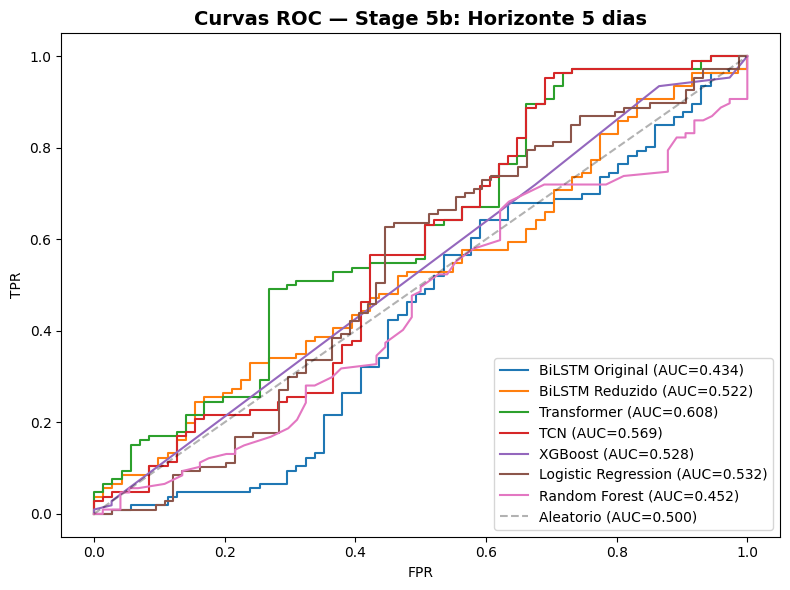

In [5]:
plot_roc_curves(results, title="Curvas ROC — Stage 5b: Horizonte 5 dias",
                save_path="results/stage5_roc.png")

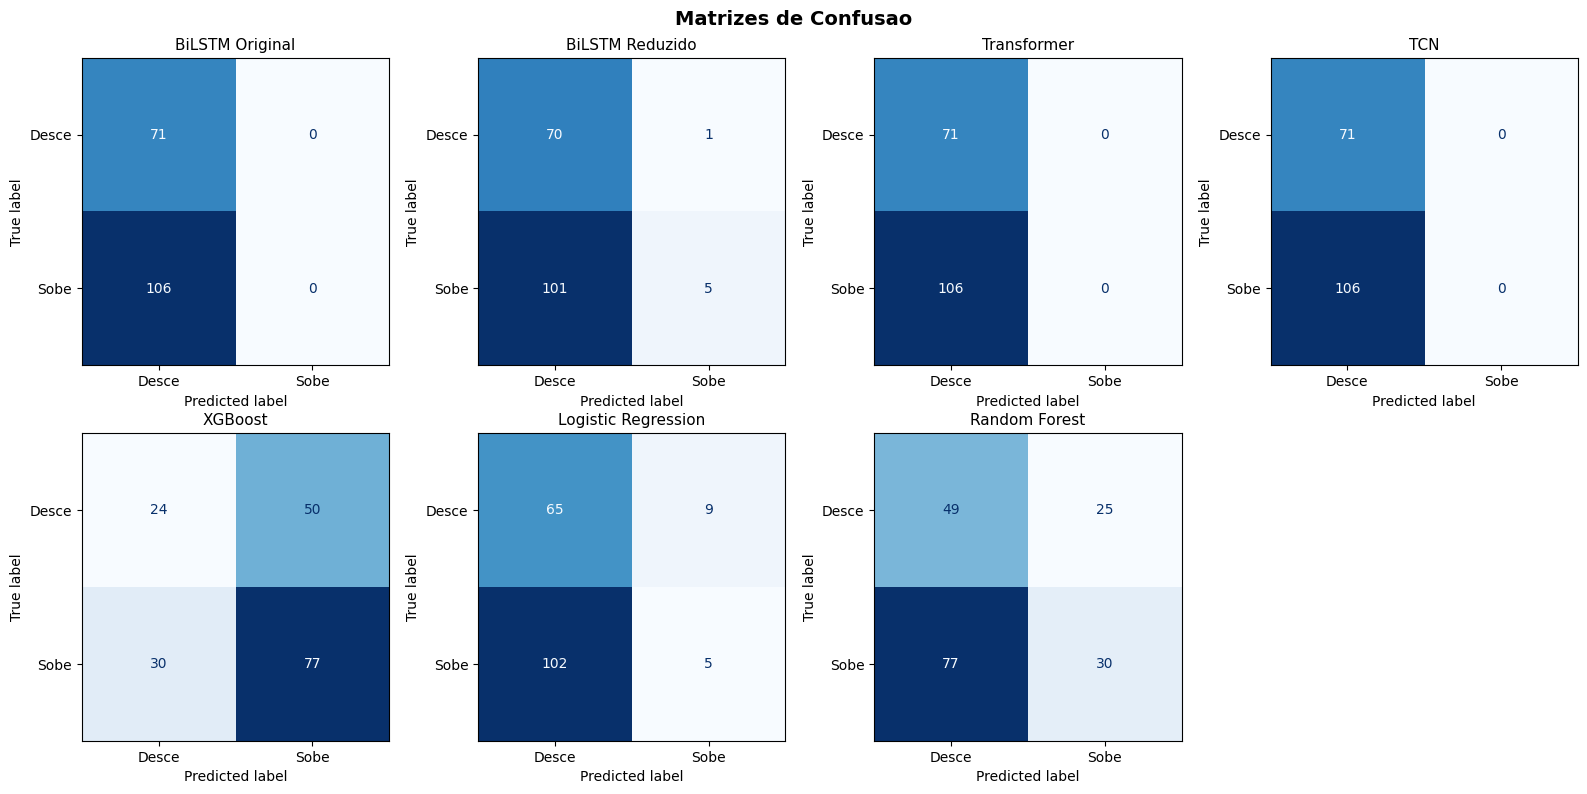

In [6]:
plot_confusion_matrices(
    {name: r["classification"] for name, r in results.items()},
    save_path="results/stage5_confusion.png",
)

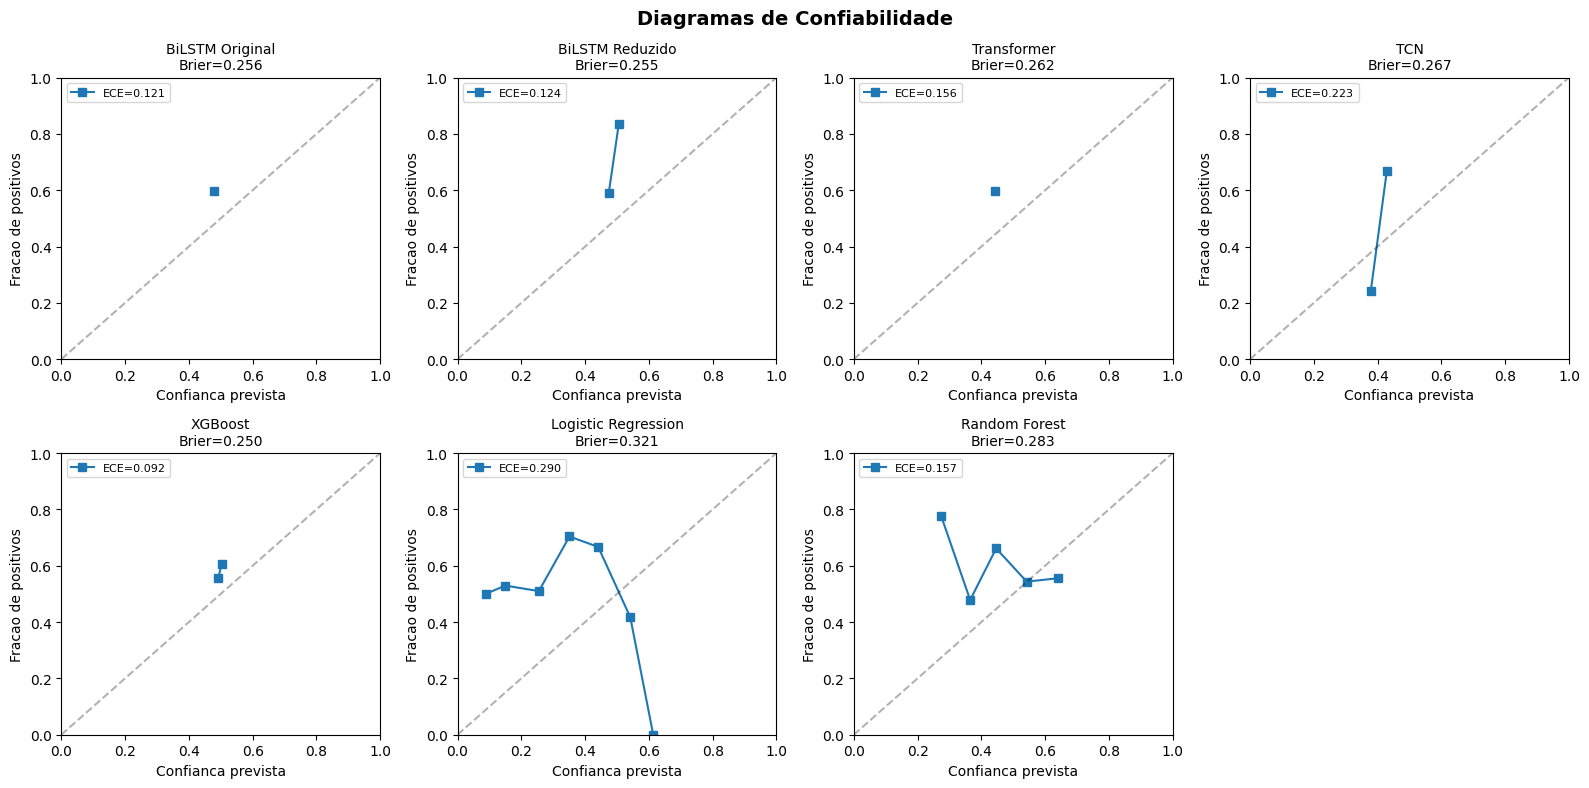

In [7]:
plot_calibration_diagrams(
    {name: r["calibration"] for name, r in results.items()},
    save_path="results/stage5_calibration.png",
)

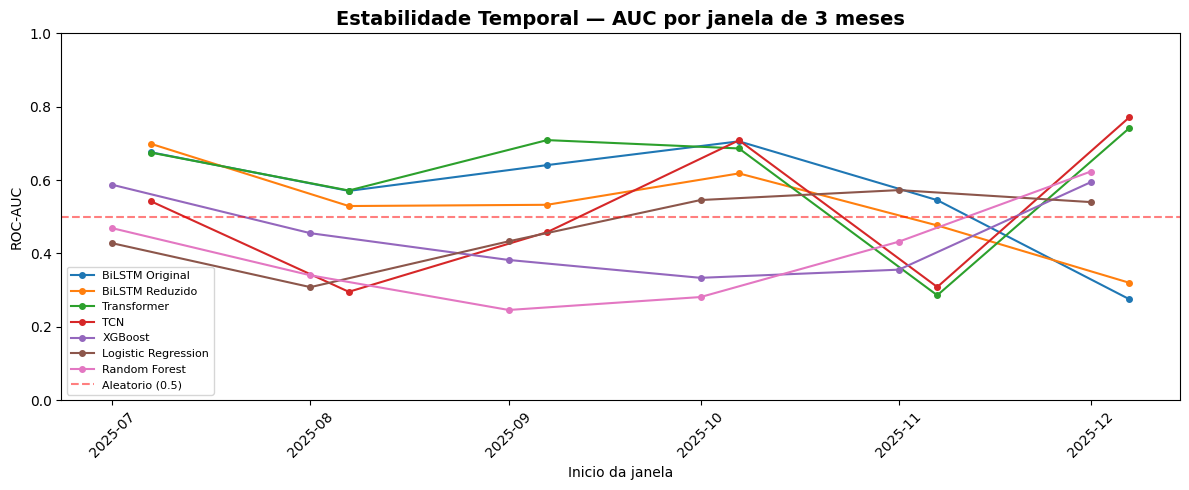

In [8]:
plot_temporal_stability(
    {name: r["temporal_stability"] for name, r in results.items()},
    save_path="results/stage5_temporal.png",
)

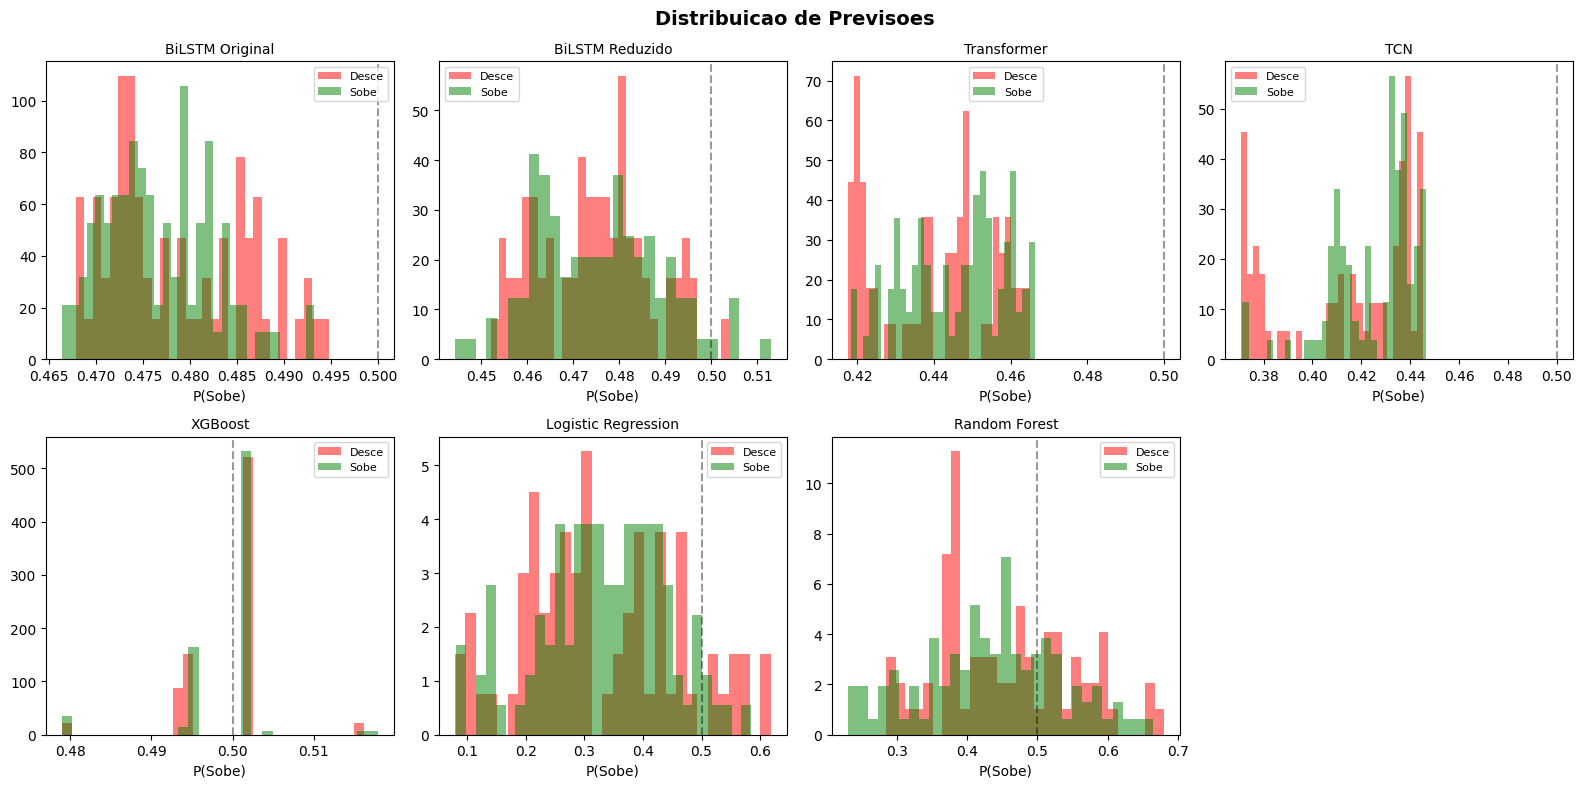

In [9]:
plot_prediction_distributions(
    {name: r["prediction_distribution"] for name, r in results.items()},
    save_path="results/stage5_distributions.png",
)

## Interpretabilidade (SHAP + Permutation Importance)

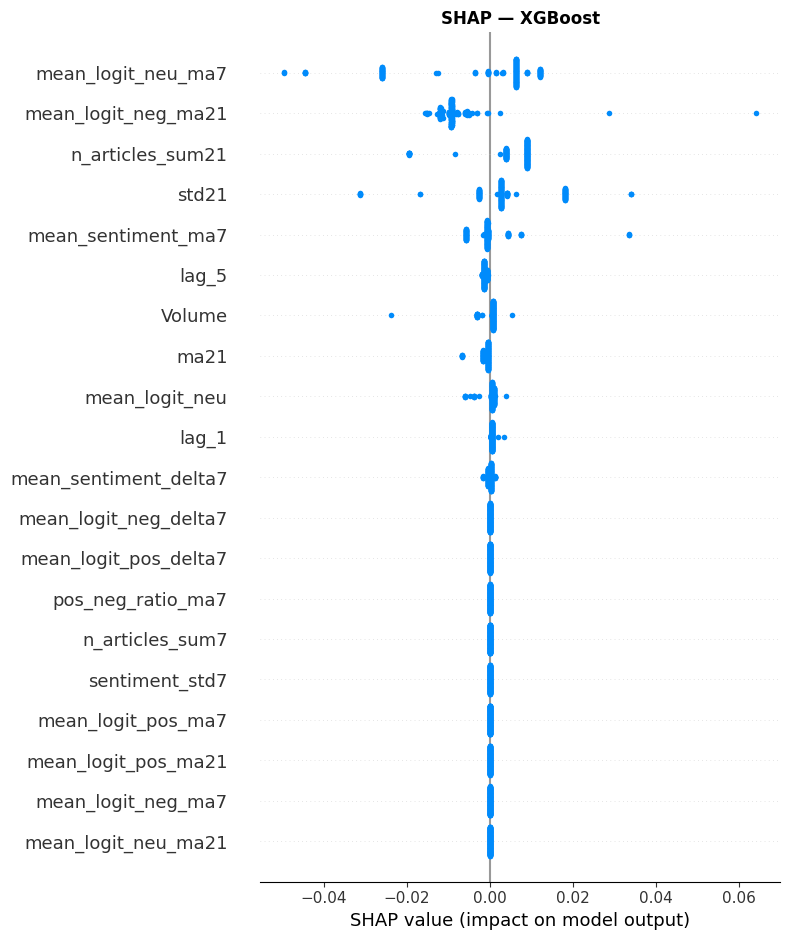

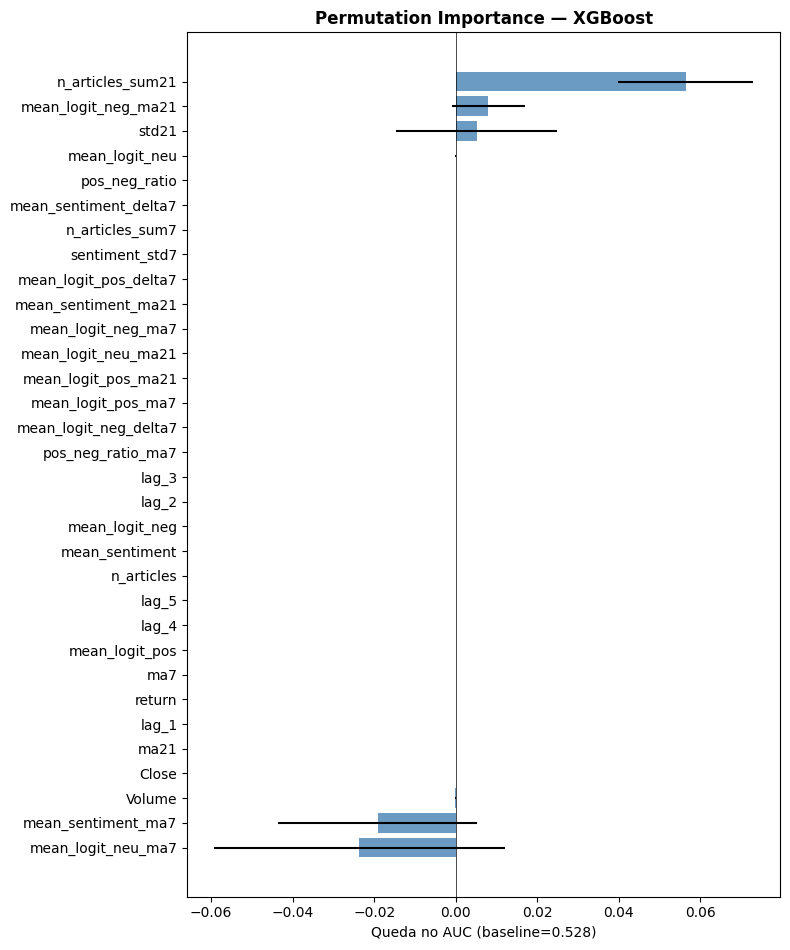

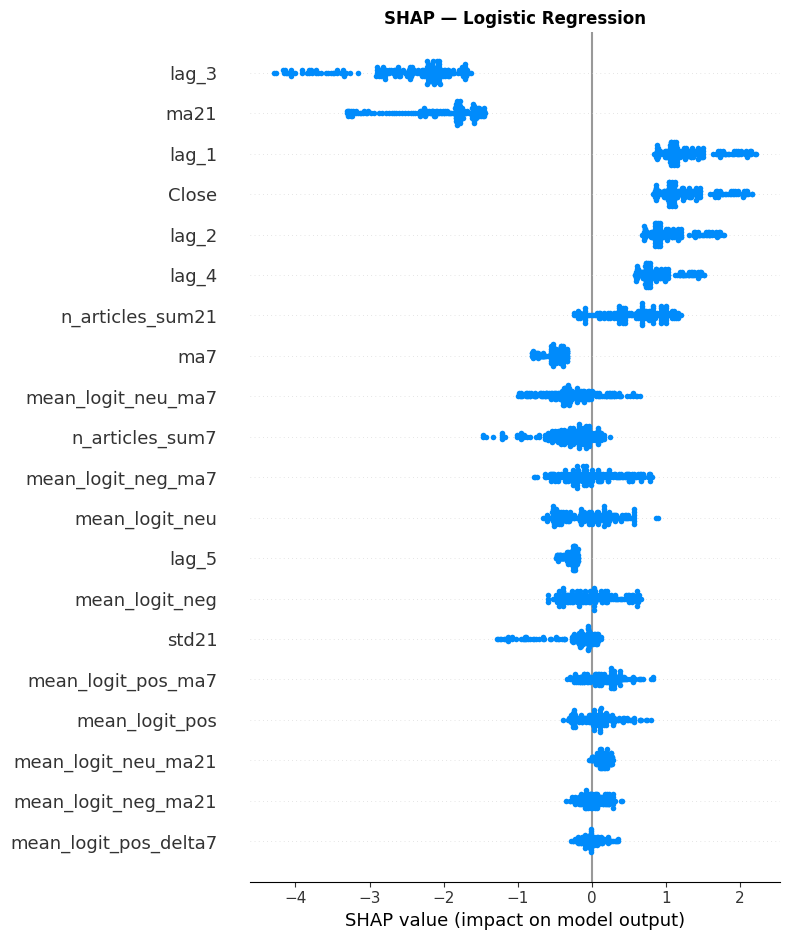

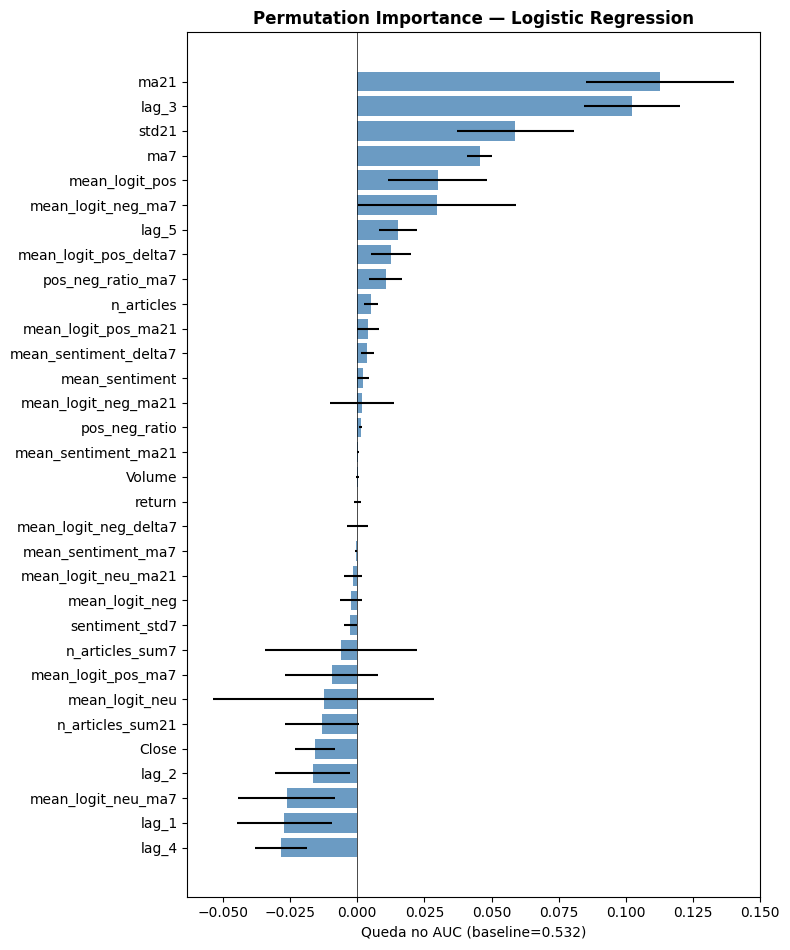

<Figure size 1000x960 with 0 Axes>

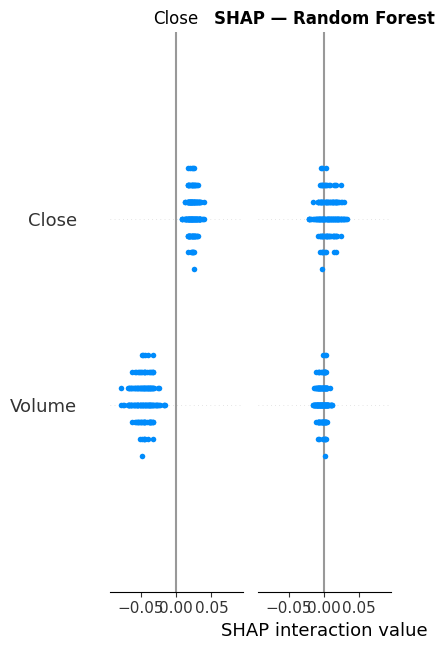

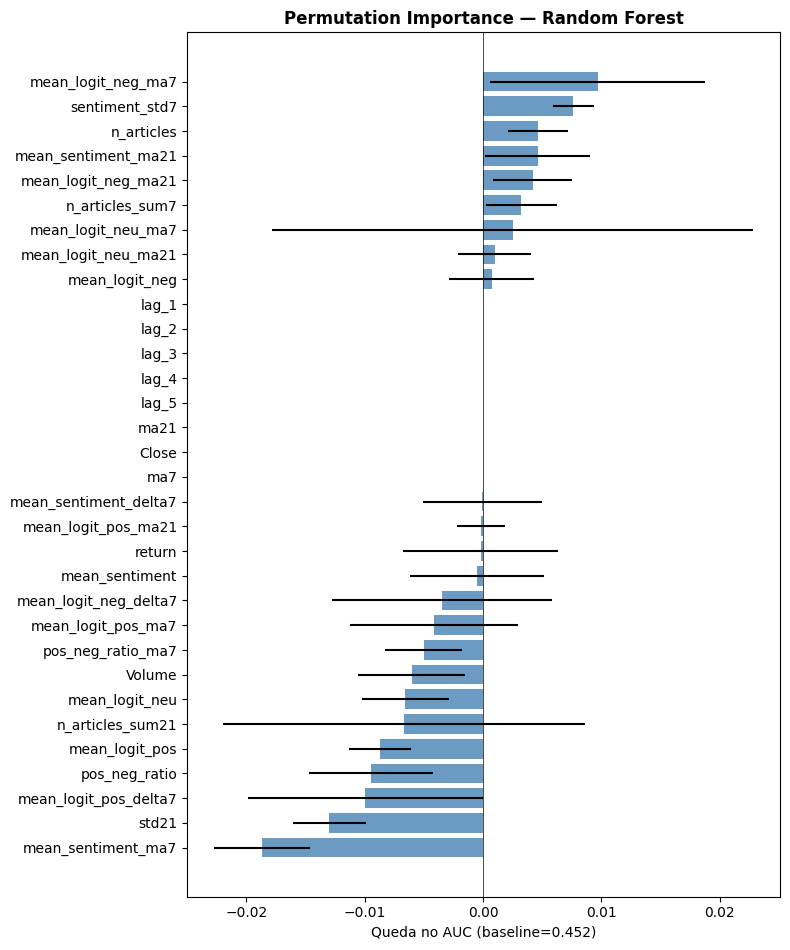

In [10]:
for name in ["XGBoost", "Logistic Regression", "Random Forest"]:
    r = results[name]
    if r["shap_values"] is not None:
        plot_shap_summary(
            r["shap_values"], data["feature_names"],
            title=f"SHAP — {name}",
            save_path=f"results/stage5_shap_{name.lower().replace(' ','_')}.png",
        )
    if r["permutation_importance"] is not None:
        plot_feature_importance(
            r["permutation_importance"],
            r["classification"]["roc_auc"],
            title=f"Permutation Importance — {name}",
            save_path=f"results/stage5_perm_{name.lower().replace(' ','_')}.png",
        )

## Curvas de aprendizado

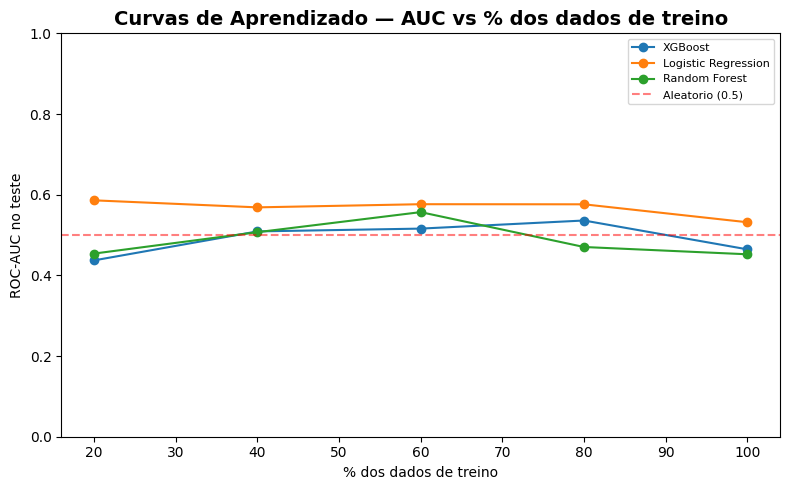

In [11]:
lc_results = {name: r["learning_curve"] for name, r in results.items()
               if r["learning_curve"] is not None}
if lc_results:
    plot_learning_curves(lc_results, save_path="results/stage5_learning_curves.png")

## Variacoes de hiperparametros

In [12]:
VARIATIONS = {
    "Transformer d=32": {"model_name": "transformer", "model_params": {"d_model": 32, "nhead": 2}},
    "Transformer d=128": {"model_name": "transformer", "model_params": {"d_model": 128, "nhead": 8}},
    "Transformer 4L": {"model_name": "transformer", "model_params": {"n_layers": 4}},
    "XGBoost depth=3": {"model_name": "xgboost", "model_params": {"max_depth": 3}},
    "XGBoost depth=6": {"model_name": "xgboost", "model_params": {"max_depth": 6}},
    "XGBoost 500 trees": {"model_name": "xgboost", "model_params": {"n_estimators": 500}},
    "BiLSTM drop=0.1": {"model_name": "bilstm_original", "model_params": {"dropout": 0.1}},
    "BiLSTM drop=0.5": {"model_name": "bilstm_original", "model_params": {"dropout": 0.5}},
    "BiLSTM h=256": {"model_name": "bilstm_original", "model_params": {"hidden_size": 256}},
    "TCN k=2": {"model_name": "tcn", "model_params": {"kernel_size": 2}},
    "TCN k=5": {"model_name": "tcn", "model_params": {"kernel_size": 5}},
    "TCN [32,32]": {"model_name": "tcn", "model_params": {"num_channels": [32, 32]}},
    "LR C=0.01": {"model_name": "logistic_regression", "model_params": {"C": 0.01}},
    "LR C=100": {"model_name": "logistic_regression", "model_params": {"C": 100}},
    "LR L1": {"model_name": "logistic_regression", "model_params": {"penalty": "l1", "solver": "saga"}},
    "RF depth=5": {"model_name": "random_forest", "model_params": {"max_depth": 5}},
    "RF depth=20": {"model_name": "random_forest", "model_params": {"max_depth": 20}},
    "RF 500 trees": {"model_name": "random_forest", "model_params": {"n_estimators": 500}},
}

var_results = {}
for display_name, config in VARIATIONS.items():
    print(f"Variacao: {display_name}")
    var_results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        model_params=config.get("model_params", {}),
        compute_shap=False,
        compute_learning_curve=False,
    )

19:01:52 [INFO] 
19:01:52 [INFO] Modelo: transformer
19:01:52 [INFO] Split — treino: 820 | val: 175 | teste: 177
19:01:52 [INFO] ============================================================
19:01:52 [INFO] Class weights: sobe=0.903, desce=1.108 (balance: 52.6% sobe)


Variacao: Transformer d=32


19:01:52 [INFO] Epoch   1/50 | loss 0.7000 | val_loss 0.6958 | val_acc 45.1% | lr 1.00e-03
19:01:52 [INFO] Epoch   2/50 | loss 0.6920 | val_loss 0.7024 | val_acc 42.3% | lr 1.00e-03
19:01:52 [INFO] Epoch   3/50 | loss 0.6872 | val_loss 0.7153 | val_acc 36.6% | lr 1.00e-03
19:01:53 [INFO] Epoch   4/50 | loss 0.6839 | val_loss 0.7341 | val_acc 34.9% | lr 1.00e-03
19:01:53 [INFO] Epoch   5/50 | loss 0.6776 | val_loss 0.7535 | val_acc 37.1% | lr 1.00e-03
19:01:53 [INFO] Epoch   6/50 | loss 0.6751 | val_loss 0.7788 | val_acc 35.4% | lr 1.00e-03
19:01:53 [INFO] Epoch   7/50 | loss 0.6672 | val_loss 0.7707 | val_acc 38.3% | lr 5.00e-04
19:01:53 [INFO] Epoch   8/50 | loss 0.6612 | val_loss 0.8005 | val_acc 37.7% | lr 5.00e-04
19:01:53 [INFO] Epoch   9/50 | loss 0.6498 | val_loss 0.7953 | val_acc 38.3% | lr 5.00e-04
19:01:53 [INFO] Epoch  10/50 | loss 0.6478 | val_loss 0.7942 | val_acc 37.7% | lr 5.00e-04
19:01:54 [INFO] Epoch  11/50 | loss 0.6401 | val_loss 0.8024 | val_acc 37.7% | lr 5.00e-04

Variacao: Transformer d=128


19:01:54 [INFO] Epoch   1/50 | loss 0.7041 | val_loss 0.6921 | val_acc 51.4% | lr 1.00e-03
19:01:54 [INFO] Epoch   2/50 | loss 0.6960 | val_loss 0.6899 | val_acc 53.1% | lr 1.00e-03
19:01:54 [INFO] Epoch   3/50 | loss 0.6923 | val_loss 0.7254 | val_acc 56.0% | lr 1.00e-03
19:01:54 [INFO] Epoch   4/50 | loss 0.6894 | val_loss 0.7205 | val_acc 53.7% | lr 1.00e-03
19:01:55 [INFO] Epoch   5/50 | loss 0.6774 | val_loss 0.7200 | val_acc 46.3% | lr 1.00e-03
19:01:55 [INFO] Epoch   6/50 | loss 0.6689 | val_loss 0.7758 | val_acc 43.4% | lr 1.00e-03
19:01:55 [INFO] Epoch   7/50 | loss 0.6562 | val_loss 0.7747 | val_acc 37.1% | lr 1.00e-03
19:01:55 [INFO] Epoch   8/50 | loss 0.6746 | val_loss 0.6933 | val_acc 48.0% | lr 5.00e-04
19:01:55 [INFO] Epoch   9/50 | loss 0.6595 | val_loss 0.7704 | val_acc 47.4% | lr 5.00e-04
19:01:56 [INFO] Epoch  10/50 | loss 0.6469 | val_loss 0.7801 | val_acc 40.6% | lr 5.00e-04
19:01:56 [INFO] Epoch  11/50 | loss 0.6393 | val_loss 0.7365 | val_acc 43.4% | lr 5.00e-04

...

19:02:14 [INFO] AUC: 0.4312 | Acc: 39.8% | F1: 0.2158 | ECE: 0.1692 | Brier: 0.2755
19:02:14 [INFO]               precision    recall  f1-score   support

       Desce       0.38      0.77      0.51        74
        Sobe       0.47      0.14      0.22       107

    accuracy                           0.40       181
   macro avg       0.43      0.46      0.36       181
weighted avg       0.43      0.40      0.34       181

19:02:21 [INFO] 
19:02:21 [INFO] Modelo: random_forest
19:02:21 [INFO] Split — treino: 841 | val: 180 | teste: 181
19:02:21 [INFO] ============================================================


Variacao: RF depth=20


19:02:21 [INFO] AUC: 0.4498 | Acc: 44.2% | F1: 0.3727 | ECE: 0.1520 | Brier: 0.2842
19:02:21 [INFO]               precision    recall  f1-score   support

       Desce       0.39      0.68      0.50        74
        Sobe       0.56      0.28      0.37       107

    accuracy                           0.44       181
   macro avg       0.47      0.48      0.44       181
weighted avg       0.49      0.44      0.42       181

19:02:27 [INFO] 
19:02:27 [INFO] Modelo: random_forest
19:02:27 [INFO] Split — treino: 841 | val: 180 | teste: 181
19:02:27 [INFO] ============================================================


Variacao: RF 500 trees


19:02:28 [INFO] AUC: 0.4365 | Acc: 39.2% | F1: 0.2949 | ECE: 0.1978 | Brier: 0.2849
19:02:28 [INFO]               precision    recall  f1-score   support

       Desce       0.36      0.65      0.47        74
        Sobe       0.47      0.21      0.29       107

    accuracy                           0.39       181
   macro avg       0.42      0.43      0.38       181
weighted avg       0.43      0.39      0.36       181



In [13]:
var_rows = []
for name, r in var_results.items():
    var_rows.append({
        "Variacao": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1": f"{r['classification']['f1']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
    })

df_var = pd.DataFrame(var_rows)
print("" + "="*60)
print("VARIACOES DE HIPERPARAMETROS")
print("="*60)
display(df_var)

VARIACOES DE HIPERPARAMETROS


,Variacao,ROC-AUC,Accuracy,F1,ECE
0,Transformer d=32,0.6313,40.1%,0.0000,0.1590
1,Transformer d=128,0.6294,40.1%,0.0000,0.2369
2,Transformer 4L,0.6314,40.1%,0.0000,0.1187
3,XGBoost depth=3,0.4912,42.0%,0.0367,0.0924
4,XGBoost depth=6,0.5210,57.5%,0.6883,0.0928
5,XGBoost 500 trees,0.5278,55.8%,0.6581,0.0916
6,BiLSTM drop=0.1,0.4563,40.1%,0.0000,0.1349
7,BiLSTM drop=0.5,0.4916,40.1%,0.0000,0.1190
8,BiLSTM h=256,0.4341,59.9%,0.7491,0.0724
9,TCN k=2,0.6265,40.1%,0.0000,0.2062


## Salvar resultados

In [14]:
all_results = {**results, **var_results}
save_results_json(all_results, "results/stage5_metrics.json")
print("Resultados salvos em results/stage5_metrics.json")

19:02:40 [INFO] Resultados salvos em results/stage5_metrics.json


Resultados salvos em results/stage5_metrics.json
